In [1]:
# Partially adapted from:
# https://scikit-learn.org/stable/auto_examples/cluster/plot_kmeans_plusplus.html
# https://scikit-learn.org/stable/auto_examples/mixture/plot_gmm_init.html

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture

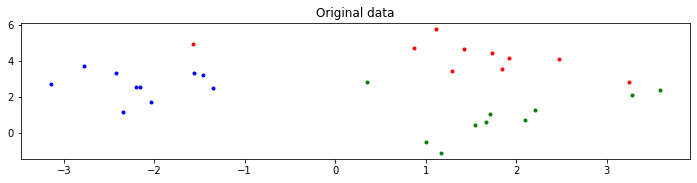

In [2]:
# After walking through this once, try changing:
#    1. the number of sample, which makes the clusters less dependent on a single outlier
#    2. the cluster_std, which adds noise making the clusters less defined
#    3. the random_state, to see what happens in slightly different settings

X1, y1 = make_blobs(n_samples=30, centers=3, n_features=2, cluster_std=1, random_state=0)

plt.figure(1, (12, 2.5))
colors = ["red", "green", "blue"]

for k, col in enumerate(colors):
    cluster_data = y1 == k
    plt.scatter(X1[cluster_data, 0], X1[cluster_data, 1], c=col, marker=".")
plt.title("Original data")
plt.show()

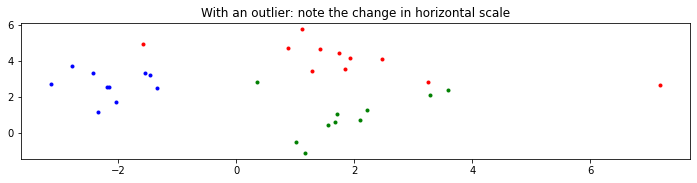

In [3]:
max_x0 = 2 * X1[:, 0].max()
mean_x1 = X1[:, 1].mean()

# Add in an outlier
X2 = np.concatenate([X1, np.array([[max_x0, mean_x1]])], axis=0)
y2 = np.concatenate([y1, [0]], axis=0)

plt.figure(1, (12, 2.5))
colors = ["red", "green", "blue"]

for k, col in enumerate(colors):
    cluster_data = y2 == k
    plt.scatter(X2[cluster_data, 0], X2[cluster_data, 1], c=col, marker=".")
plt.title("With an outlier: note the change in horizontal scale")
plt.show()

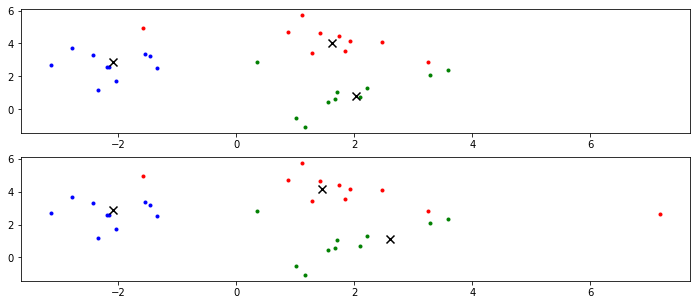

In [4]:
# Fit k-means to both
X1_Kmeans = KMeans(n_clusters=3, random_state=0).fit(X1)
centers1 = X1_Kmeans.cluster_centers_

X2_Kmeans = KMeans(n_clusters=3, random_state=0).fit(X2)
centers2 = X2_Kmeans.cluster_centers_

fig, axs = plt.subplots(
    2, 1, figsize=(12, 5)
)

colors = ["red", "green", "blue"]

for k, col in enumerate(colors):
    cluster_data = y1 == k
    axs[0].scatter(X1[cluster_data, 0], X1[cluster_data, 1], c=col, marker=".")
    cluster_data = y2 == k
    axs[1].scatter(X2[cluster_data, 0], X2[cluster_data, 1], c=col, marker=".")
    
axs[0].scatter(centers1[:, 0], centers1[:, 1], c='black', marker='x', s=64)
axs[1].scatter(centers2[:, 0], centers2[:, 1], c='black', marker='x', s=64)
axs[0].set_xlim(axs[1].get_xlim())
plt.show()

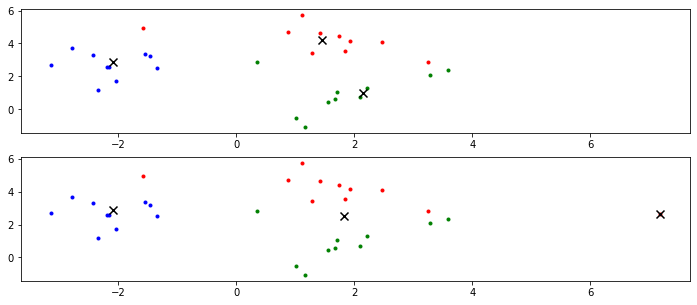

In [5]:
# Fit GMMs to both
X1_GMM = GaussianMixture(n_components=3, random_state=0).fit(X1)
means1 = X1_GMM.means_

X2_GMM = GaussianMixture(n_components=3, random_state=0).fit(X2)
means2 = X2_GMM.means_

fig, axs = plt.subplots(
    2, 1, figsize=(12, 5)
)

colors = ["red", "green", "blue"]

for k, col in enumerate(colors):
    cluster_data = y1 == k
    axs[0].scatter(X1[cluster_data, 0], X1[cluster_data, 1], c=col, marker=".")
    cluster_data = y2 == k
    axs[1].scatter(X2[cluster_data, 0], X2[cluster_data, 1], c=col, marker=".")
    
axs[0].scatter(means1[:, 0], means1[:, 1], c='black', marker='x', s=64)
axs[1].scatter(means2[:, 0], means2[:, 1], c='black', marker='x', s=64)
axs[0].set_xlim(axs[1].get_xlim())
plt.show()

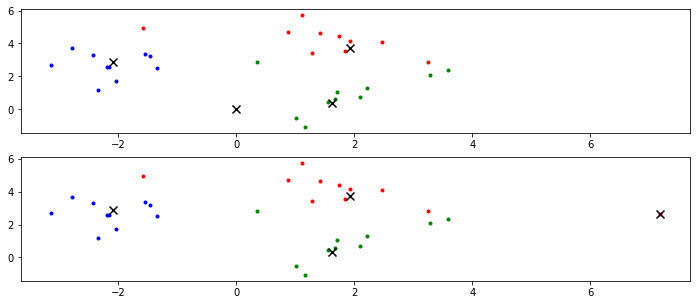

In [6]:
# Take the GMM fit to the outlier dataset and use its means and covariances
#    to initialize a new GMM, but add an additional cluster to the new GMM
#    that has mean=0 and covariance=I.
# Fit this new GMM to the dataset with and without the outlier

means_init = np.concatenate([X2_GMM.means_, np.array([[0, 0]])], axis=0)
new_precision = (np.eye(2)).reshape(1, 2, 2)
precisions_init = np.concatenate([X2_GMM.precisions_, new_precision], axis=0)

X1_GMM_4c = GaussianMixture(
    n_components=4, random_state=0,
    means_init=means_init,
    precisions_init=precisions_init
).fit(X1)
means1_4c = X1_GMM_4c.means_

X2_GMM_4c = GaussianMixture(
    n_components=4, random_state=0,
    means_init=means_init,
    precisions_init=precisions_init
).fit(X2)
means2_4c = X2_GMM_4c.means_

fig, axs = plt.subplots(
    2, 1, figsize=(12, 5)
)

colors = ["red", "green", "blue"]

for k, col in enumerate(colors):
    cluster_data = y1 == k
    axs[0].scatter(X1[cluster_data, 0], X1[cluster_data, 1], c=col, marker=".")
    cluster_data = y2 == k
    axs[1].scatter(X2[cluster_data, 0], X2[cluster_data, 1], c=col, marker=".")
    
axs[0].scatter(means1_4c[:, 0], means1_4c[:, 1], c='black', marker='x', s=64)
axs[1].scatter(means2_4c[:, 0], means2_4c[:, 1], c='black', marker='x', s=64)
axs[0].set_xlim(axs[1].get_xlim())
plt.show()

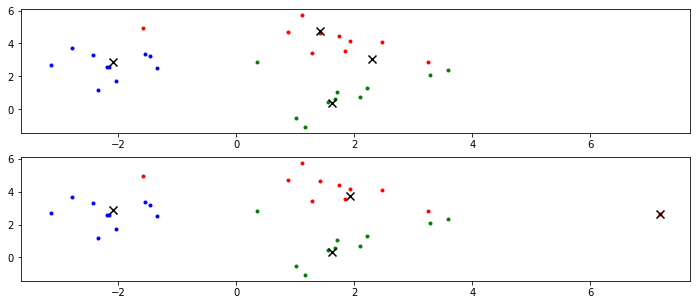

In [7]:
# Take the Kmeans fit to the outlier dataset and use its means
#    to initialize a new Kmean, but add an additional mean
# Fit this new KMeans to the dataset with and without the outlier

means_init = np.concatenate([X2_GMM.means_, np.array([[0, 0]])], axis=0)


X1_KMeans_4c = KMeans(
    n_clusters=4, random_state=0,
    init=means_init,
    n_init=1
).fit(X1)
clusters1_4c = X1_KMeans_4c.cluster_centers_

X2_KMeans_4c = KMeans(
    n_clusters=4, random_state=0,
    init=means_init,
    n_init=1
).fit(X2)
clusters2_4c = X2_KMeans_4c.cluster_centers_

fig, axs = plt.subplots(
    2, 1, figsize=(12, 5)
)

colors = ["red", "green", "blue"]

for k, col in enumerate(colors):
    cluster_data = y1 == k
    axs[0].scatter(X1[cluster_data, 0], X1[cluster_data, 1], c=col, marker=".")
    cluster_data = y2 == k
    axs[1].scatter(X2[cluster_data, 0], X2[cluster_data, 1], c=col, marker=".")
    
axs[0].scatter(clusters1_4c[:, 0], clusters1_4c[:, 1], c='black', marker='x', s=64)
axs[1].scatter(clusters2_4c[:, 0], clusters2_4c[:, 1], c='black', marker='x', s=64)
axs[0].set_xlim(axs[1].get_xlim())
plt.show()